# Giữ điểm ảnh gốc hay qua phép nội suy co giãn?

Ở [Bài 03](03_pretrained_and_finetune.ipynb), cấu hình `center60` cắt một vùng ảnh khoảng 307x307 ở trung tâm rồi co giãn (resize) về kích thước chuẩn 224x224. Việc co giãn này làm thay đổi giá trị điểm ảnh thông qua phép nội suy bilinear.

Nếu các dấu vết can thiệp kỹ thuật số nằm ở các chi tiết vi mô, phép nội suy có thể làm mất tín hiệu đó. Tuy nhiên, nếu chuyển sang lấy một vùng cắt nhỏ 224x224, ta cũng đồng thời thay đổi phạm vi vùng nhìn (field of view) của mạng. Chỉ so sánh `center60` (vùng nhìn rộng, có nội suy) với một vùng cắt 224x224 (vùng nhìn hẹp, không nội suy) sẽ làm thay đổi hai yếu tố cùng lúc; ta không thể phân biệt kết quả đến từ việc giữ điểm ảnh hay từ việc thay đổi vùng nhìn.

Phương án Native thử mở rộng vùng nhìn bằng 4 vùng cắt 224x224 giữ nguyên tỉ lệ 1:1 trên ảnh 512x512. Để tách riêng tác động nội suy, ta thiết lập đối chứng Resampled: lấy đúng 4 vùng cắt đó nhưng thu nhỏ về 112x112 rồi phóng to trở lại 224x224. Cả hai mô hình đều có cùng kiến trúc DenseNet-121, cùng 4 vùng nhìn, cùng hàm mất mát và cùng ngân sách 19 epoch cố định. Notebook này khảo sát vùng nhìn, đo đạc chi tiết ảnh và so sánh hai mô hình trên tập kiểm định Fold 0. Kết quả bài này không dùng để chọn backbone, size hay vùng nhìn cho các bài sau.


In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as TF

from kmd.core import PACKAGE, read_csv, split_fold, metric, read_json
from kmd.config import Config
from kmd.presets import get_preset_config
from kmd.data import Pairs
from kmd.models import model_for
from kmd.pipeline import prepare_development, load_session, train_cnn_fold, aligned_predictions
from kmd.teaching import resolve_data_roots, plot_crop_overlay_512, plot_patch_zoom_comparison

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "Huấn luyện và đánh giá mô hình Native yêu cầu GPU hỗ trợ CUDA. "
        "Vui lòng sử dụng máy có GPU hoặc thực hành các mô hình baseline tại bài 01 và 02."
    )

dev_frame = prepare_development(data_root)
session_dir = load_session(RUN_ID, data_root)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.name} (smoke={KMD_SMOKE})")
print(f"Thiết bị tính toán: {torch.cuda.get_device_name(0)}")
print(f"Tổng số cặp phát triển: {len(dev_frame)}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: lesson_full_v5_20260920 (smoke=False)
Thiết bị tính toán: NVIDIA GeForce RTX 5060 Ti
Tổng số cặp phát triển: 800


## 1. Vì sao dùng 4 vùng nhìn và tọa độ heuristic?

Một vùng cắt $224 \times 224$ chỉ chiếm khoảng $19\%$ diện tích của ảnh gốc $512 \times 512$. Nếu chỉ lấy duy nhất một vùng cắt ở giữa ảnh, các chi tiết nằm ngoài khung sẽ không đi vào mạng. Ta chưa biết chúng có hữu ích cho dự đoán không.

Phương án Native sử dụng 4 vùng cắt $224 \times 224$ quanh các tâm tọa độ chuẩn hóa:
1. Vùng 1 (Trung tâm): $(0.50, 0.50)$
2. Vùng 2 (Trên trái): $(0.38, 0.38)$
3. Vùng 3 (Trên phải): $(0.62, 0.38)$
4. Vùng 4 (Dưới): $(0.50, 0.64)$

Hai đặc tính thiết kế quan trọng cần lưu ý:
- Tọa độ mang tính heuristic: Các tọa độ này được chọn dựa trên vị trí thông thường của các phần trên khuôn mặt căn giữa. Chúng không được định vị bằng facial landmarks và chưa được chứng minh là bộ tọa độ tối ưu.
- Chồng lấp không gian: Bốn vùng cắt có phần diện tích chồng lấp đáng kể lên nhau. Chúng không phải là 4 quan sát độc lập về mặt thống kê.

Dưới đây là hình vẽ biểu diễn vị trí 4 vùng cắt Native và vùng nhìn Center60 trên một ảnh mẫu 512x512.

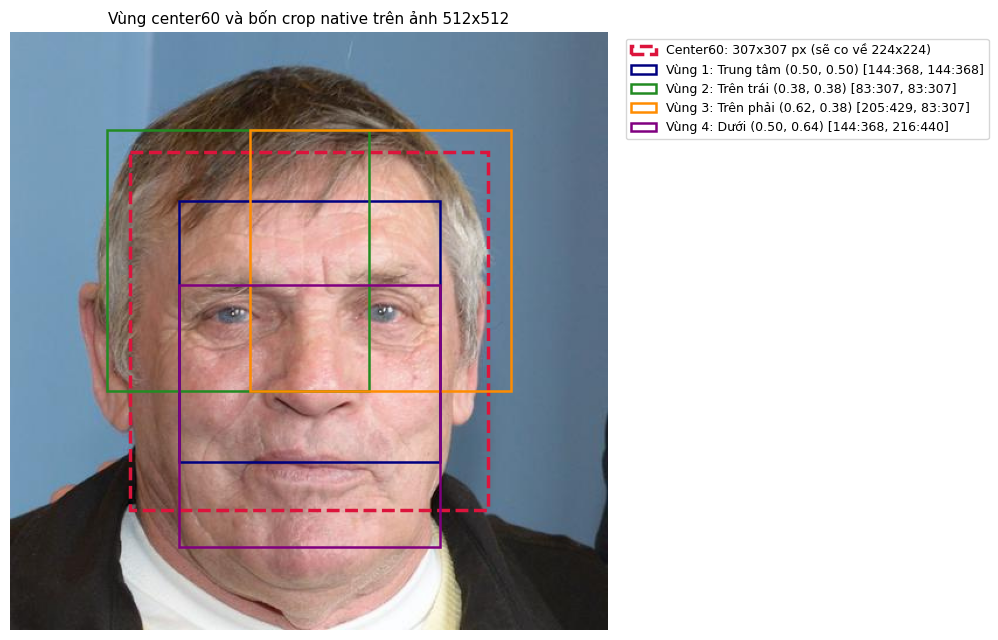

In [2]:
tr_fold0, va_fold0 = split_fold(dev_frame, fold=0)
sample_row = tr_fold0.sort_values('pair_id').iloc[0]
sample_img_path = data_root / sample_row.image_0

plot_crop_overlay_512(sample_img_path)

## 2. Quan sát phóng to điểm ảnh: Native so với Resampled

Để đánh giá tác động của phép nội suy trong cùng một vùng nhìn, ta tạo mẫu đối chứng trực tiếp: lấy đúng vùng cắt 224x224 ở trung tâm, thu nhỏ về 112x112 rồi phóng to trở lại 224x224 bằng phép nội suy bilinear.

Cả hai mẫu đều quan sát cùng một vị trí trên khuôn mặt. Một bên giữ nguyên điểm ảnh gốc 1:1, bên kia đã trải qua hai lần nội suy. Khi phóng to một ô nhỏ 64x64 điểm ảnh, hãy xem đường biên và chi tiết nhỏ thay đổi ở đâu, hoặc liệu khác biệt có quá nhỏ để nhận ra bằng mắt.

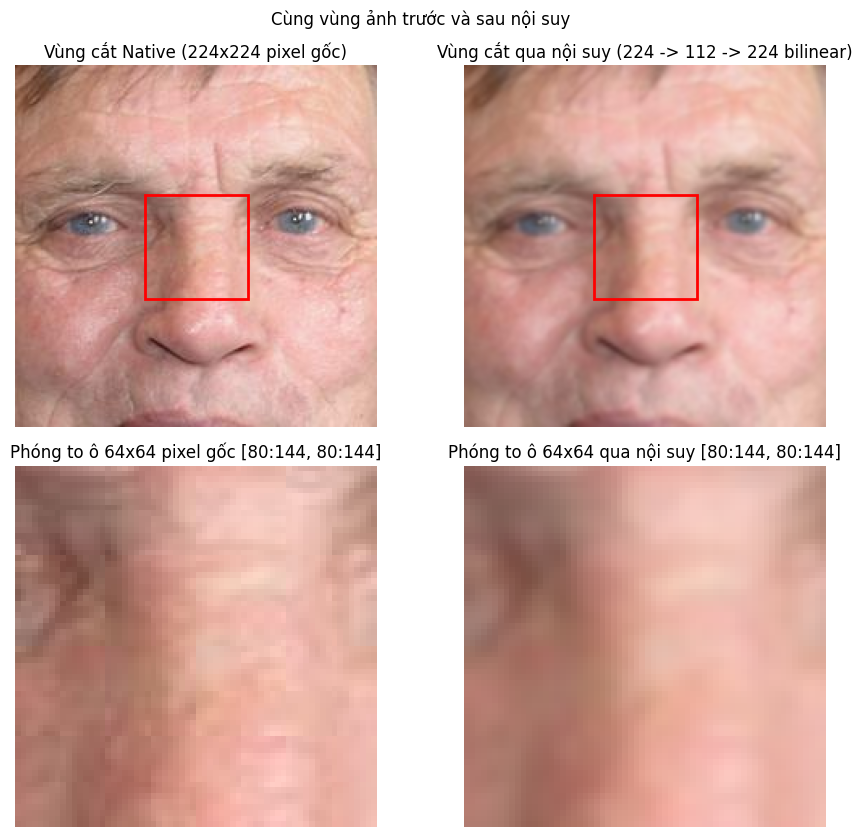

In [3]:
plot_patch_zoom_comparison(sample_img_path, zoom_box=(80, 80, 144, 144))

## 3. Đo lường định lượng chi tiết ở cấp độ ảnh

Ta đo lường sự thay đổi chi tiết bằng hai chỉ số:
- Độ lớn gradient Sobel: phản ánh độ dốc biên độ sáng cục bộ.
- Độ lệch chuẩn phần dư Gaussian (sigma = 1.2): đo mức độ biến thiên của chi tiết nhỏ so với phiên bản làm mờ.

Quy tắc tính toán: Với mỗi ảnh, ta tính gradient và residual trên cả 4 vùng cắt, sau đó lấy trung bình cấp ảnh. Điều này bảo đảm mỗi ảnh chỉ đóng góp đúng một quan sát, tránh đếm 4 vùng cắt chồng lấp thành 4 quan sát độc lập.

Sự suy giảm gradient hay residual là đặc tính mô tả của thao tác nội suy làm mờ ảnh; nó không chứng minh cơ chế nhân quả rằng mô hình dự đoán tốt hơn hay kém hơn là do các chỉ số này.

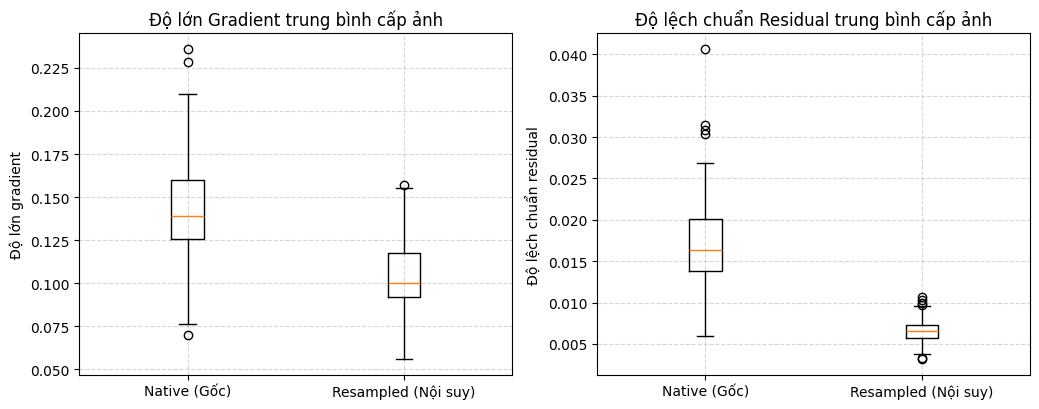

Trung vị Gradient:  Native = 0.1389 | Resampled = 0.1003
Trung vị Residual:  Native = 0.0163 | Resampled = 0.0065


In [4]:
# Khảo sát định lượng trên tập mẫu gồm 40 cặp đầu tiên của tập train Fold 0
subset_rows = tr_fold0.sort_values('pair_id').head(40)
centers = [(0.5, 0.5), (0.38, 0.38), (0.62, 0.38), (0.5, 0.64)]

nat_res_stds, resamp_res_stds = [], []
nat_grad_means, resamp_grad_means = [], []

for r in subset_rows.itertuples():
    for path_rel in (r.image_0, r.image_1):
        p = data_root / path_rel
        with Image.open(p) as img:
            im = img.convert('RGB')
            w, h = im.size
        
        curr_nat_std, curr_res_std = [], []
        curr_nat_grad, curr_res_grad = [], []
        
        for cx, cy in centers:
            left = max(0, min(w - 224, round(cx * w) - 112))
            top = max(0, min(h - 224, round(cy * h) - 112))
            patch = im.crop((left, top, left + 224, top + 224))
            
            patch_resamp = TF.resize(TF.resize(patch, [112, 112], antialias=True), [224, 224], antialias=True)
            
            g_nat = np.array(patch.convert('L'), dtype=np.float32) / 255.0
            g_res = np.array(patch_resamp.convert('L'), dtype=np.float32) / 255.0
            
            gx_n = cv2.Sobel(g_nat, cv2.CV_32F, 1, 0, ksize=3)
            gy_n = cv2.Sobel(g_nat, cv2.CV_32F, 0, 1, ksize=3)
            curr_nat_grad.append(np.sqrt(gx_n**2 + gy_n**2).mean())
            
            gx_r = cv2.Sobel(g_res, cv2.CV_32F, 1, 0, ksize=3)
            gy_r = cv2.Sobel(g_res, cv2.CV_32F, 0, 1, ksize=3)
            curr_res_grad.append(np.sqrt(gx_r**2 + gy_r**2).mean())
            
            b_n = cv2.GaussianBlur(g_nat, (0, 0), 1.2)
            curr_nat_std.append((g_nat - b_n).std())
            
            b_r = cv2.GaussianBlur(g_res, (0, 0), 1.2)
            curr_res_std.append((g_res - b_r).std())
            
        nat_res_stds.append(np.mean(curr_nat_std))
        resamp_res_stds.append(np.mean(curr_res_std))
        nat_grad_means.append(np.mean(curr_nat_grad))
        resamp_grad_means.append(np.mean(curr_res_grad))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].boxplot([nat_grad_means, resamp_grad_means], tick_labels=['Native (Gốc)', 'Resampled (Nội suy)'])
axes[0].set_title("Độ lớn Gradient trung bình cấp ảnh")
axes[0].set_ylabel("Độ lớn gradient")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].boxplot([nat_res_stds, resamp_res_stds], tick_labels=['Native (Gốc)', 'Resampled (Nội suy)'])
axes[1].set_title("Độ lệch chuẩn Residual trung bình cấp ảnh")
axes[1].set_ylabel("Độ lệch chuẩn residual")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(f"Trung vị Gradient:  Native = {np.median(nat_grad_means):.4f} | Resampled = {np.median(resamp_grad_means):.4f}")
print(f"Trung vị Residual:  Native = {np.median(nat_res_stds):.4f} | Resampled = {np.median(resamp_res_stds):.4f}")

## 4. Cơ chế Multi-crop Mean Logit Pooling và tính toán 8 Logits

Khi đưa một cặp ảnh $(image_0, image_1)$ vào mô hình Native, mỗi ảnh tạo ra 4 vùng cắt, tổng cộng 8 vùng cắt đưa qua mạng DenseNet-121.

Mạng tính ra 8 giá trị logit:
- 4 logit cho $image_0$: $z_0^{(1)}, z_0^{(2)}, z_0^{(3)}, z_0^{(4)}$
- 4 logit cho $image_1$: $z_1^{(1)}, z_1^{(2)}, z_1^{(3)}, z_1^{(4)}$

Điểm số đại diện cho mỗi ảnh được tính bằng trung bình cộng các logit thành phần:

$$s_0 = \frac{1}{4} \sum_{k=1}^4 z_0^{(k)}, \qquad s_1 = \frac{1}{4} \sum_{k=1}^4 z_1^{(k)}$$

Xác suất dự đoán cho toàn cặp: $p = \sigma(s_1 - s_0)$. Đây là trung bình logit trước khi lấy hiệu, khác với trung bình các xác suất; bài này chưa đối chứng hai quy tắc ấy.

Đoạn mã dưới đây minh họa phép tính này trên một cặp mẫu bằng mô hình chưa huấn luyện.

In [5]:
c_nat_cfg = Config(**read_json(TASK_ROOT / 'configs/native.json'))
device = 'cuda' if torch.cuda.is_available() else 'cpu'

m_pool, _ = model_for(c_nat_cfg, device=device, pretrained=False)
m_pool.eval()

one_row = tr_fold0.sort_values('pair_id').head(1)
ds_one = Pairs(one_row, data_root, c_nat_cfg, training=False)
x_pair, y_pair = ds_one[0]
x_pair = x_pair.unsqueeze(0).to(device)  # Kích thước: [1, 2, 4, 3, 224, 224]

with torch.no_grad():
    crops_in = x_pair.reshape(8, 3, 224, 224)
    eight_logits = m_pool(crops_in).reshape(2, 4).cpu().numpy()
    
    mean_s0 = float(eight_logits[0].mean())
    mean_s1 = float(eight_logits[1].mean())
    p_final = float(torch.sigmoid(torch.tensor(mean_s1 - mean_s0)).item())

print(f"Cặp mẫu: {one_row.iloc[0].pair_id} | Nhãn thực tế: {int(y_pair)}")
print("\nBảng 8 giá trị logit phân bố qua 4 vùng cắt:")
df_8log = pd.DataFrame(
    eight_logits,
    index=['image_0', 'image_1'],
    columns=['Vùng 1 (Giữa)', 'Vùng 2 (Trên trái)', 'Vùng 3 (Trên phải)', 'Vùng 4 (Dưới)']
)
print(df_8log.to_string())
print(f"\nĐiểm số trung bình s0: {mean_s0:.4f}")
print(f"Điểm số trung bình s1: {mean_s1:.4f}")
print(f"Độ chênh lệch (s1 - s0): {mean_s1 - mean_s0:.4f}")
print(f"Xác suất p(phải giả):   {p_final:.4f}")

del m_pool
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Cặp mẫu: 00001 | Nhãn thực tế: 1

Bảng 8 giá trị logit phân bố qua 4 vùng cắt:
         Vùng 1 (Giữa)  Vùng 2 (Trên trái)  Vùng 3 (Trên phải)  Vùng 4 (Dưới)
image_0      -0.560687           -0.530593           -0.540580      -0.533888
image_1      -0.649383           -0.753829           -0.640894      -0.615607

Điểm số trung bình s0: -0.5414
Điểm số trung bình s1: -0.6649
Độ chênh lệch (s1 - s0): -0.1235
Xác suất p(phải giả):   0.4692


## 5. Huấn luyện đối chứng trên Fold 0: Native so với Resampled

Ta tiến hành huấn luyện hai mô hình đối chứng trên cùng tập dữ liệu kiểm định Fold 0:
- `native`: Sử dụng 4 vùng cắt 224x224 nguyên bản 1:1.
- `resampled`: Sử dụng cùng 4 vùng cắt đó nhưng qua phép nội suy co giãn 224 -> 112 -> 224.

Cả hai mô hình đều dùng chung kiến trúc DenseNet-121, cùng microbatch 8, cùng hàm mất mát BCE và cùng kết thúc tại 19 epoch cố định (`fixed_epochs=True`, `epochs=19`). Điểm khác biệt duy nhất được cô lập là thao tác nội suy lên điểm ảnh.

In [6]:
folder_nat, res_nat = train_cnn_fold('native', dev_frame, data_root, session_dir, fold=0, smoke=KMD_SMOKE)
folder_res, res_res = train_cnn_fold('resampled', dev_frame, data_root, session_dir, fold=0, smoke=KMD_SMOKE)

df_eval = pd.DataFrame([
    {'Mô hình': '1. Native (4 vùng cắt gốc 1:1)', **res_nat['metrics']},
    {'Mô hình': '2. Resampled Control (nội suy 112 -> 224)', **res_res['metrics']},
])
print("Kết quả đối chứng trên tập kiểm định Fold 0:")
display_cols = ['Mô hình', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print(df_eval[display_cols].to_string(index=False))

native_s20260917_f0: epoch 1/19, loss=0.7065, current_F1=0.5877, best=0.5877


native_s20260917_f0: epoch 2/19, loss=0.6796, current_F1=0.7228, best=0.7228


native_s20260917_f0: epoch 3/19, loss=0.5437, current_F1=0.9288, best=0.9288


native_s20260917_f0: epoch 4/19, loss=0.3585, current_F1=0.9625, best=0.9625


native_s20260917_f0: epoch 5/19, loss=0.3211, current_F1=0.9663, best=0.9663


...

resampled_s20260917_f0: epoch 16/19, loss=0.2096, current_F1=0.9588, best=0.9588


resampled_s20260917_f0: epoch 17/19, loss=0.0298, current_F1=0.9625, best=0.9625


resampled_s20260917_f0: epoch 18/19, loss=0.0805, current_F1=0.9625, best=0.9625


resampled_s20260917_f0: epoch 19/19, loss=0.0702, current_F1=0.9625, best=0.9625


Kết quả đối chứng trên tập kiểm định Fold 0:
                                  Mô hình  macro_f1  accuracy  log_loss  errors
           1. Native (4 vùng cắt gốc 1:1)  0.985019  0.985019  0.107837       4
2. Resampled Control (nội suy 112 -> 224)  0.962542  0.962547  0.213888      10


## 6. Đọc kết quả đối chứng và giới hạn suy luận

Quan sát kết quả Macro-F1 và số lỗi thực tế trong bảng trên:
- Nếu Native đạt điểm số cao hơn và ít lỗi hơn Resampled, kết quả ủng hộ việc giữ nguyên điểm ảnh gốc trong thiết lập đối chứng cụ thể này.
- Nếu hai nhánh ngang nhau, chưa có lợi thế rõ của giữ điểm ảnh trong phép thử. Nếu Resampled tốt hơn, phải giữ kết quả đó và xem lại giả thuyết thay vì loại bỏ lượt chạy.
- Giới hạn suy luận: Kết quả đối chứng áp dụng cho cùng kiến trúc DenseNet-121, cùng 4 vùng cắt và cùng 19 epoch. Ta không thể kết luận rằng Native sẽ vượt trội hơn mọi mô hình sử dụng ảnh co giãn, chẳng hạn các mạng có kiến trúc khác hoặc độ phân giải lớn hơn.

Phép thử Native/Resampled chỉ cô lập nội suy trên DenseNet-121. Nó không chọn backbone, không chọn size 224 hay 288, và không chọn vùng nhìn 60% hay 72%.

Thí nghiệm về tinh chỉnh từng phần (partial fine-tuning) được phân tách thành câu hỏi riêng trong bài mở rộng A (`extension_a_representations.ipynb`).

[Bài 05](05_backbone_and_selection.ipynb) tách size, vùng nhìn và backbone trên cùng ngân sách 48 epoch, rồi mới chọn một mô hình đơn trên 800 cặp phát triển.
